# Modélisation de l'indice des prix immobiliers par un processus d'Ornstein Uhlenbeck

## Introduction

Dans ce projet, on s'intéresse à l'évolution de l'indice des prix immobiliers publié par l'INSEE.

L'objectif est de vérifier dans quelle mesure un processus d'Ornstein–Uhlenbeck permet de reproduire la dynamique observée sur les données historiques et d'obtenir des projections à moyen terme.

Le travail est organisé en plusieurs étapes :

- préparation et analyse des données ;
- calibration des paramètres du modèle ;
- simulation de trajectoires futures ;
- estimation de probabilités associées à différents scénarios ;
- comparaison de plusieurs variantes du modèle.

L'ensemble des calculs est réalisé en Python à partir des séries trimestrielles observées.


## 1. Importation des bibliothèques

Les bibliothèques utilisées dans ce notebook couvrent la manipulation des données, les calculs statistiques, les simulations Monte‑Carlo et la visualisation des résultats.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy import stats
from scipy.stats import norm
from numpy.polynomial import Polynomial
import warnings
warnings.filterwarnings('ignore')

# Reproductibilité
SEED = 42
rng = np.random.default_rng(SEED)

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11,
})

print('Libraries loaded.')

Libraries loaded.


## 2. Chargement et préparation des données

Les données sont importées puis mises en forme afin d'obtenir une série temporelle trimestrielle directement exploitable pour la suite de l'étude.


In [2]:
#  Chargement du CSV INSEE 
# Le fichier INSEE est encodé en Latin-1 
raw = pd.read_csv('valeurs_trimestrielles.csv', sep=';', header=0, encoding='latin-1')

# idBank est lu comme float 
TARGET_ID = 10001868

mask = (raw['idBank'] == TARGET_ID)
row  = raw[mask].iloc[0]   # ligne données de la série nationale brute

# Colonnes temporelles 
time_cols = [c for c in raw.columns if len(c) >= 6 and c[:4].isdigit() and '-T' in c]

# Construction de la série temporelle propre
values = pd.to_numeric(row[time_cols], errors='coerce')
values.index = pd.PeriodIndex(
    [c.replace('-T', 'Q') for c in time_cols], freq='Q'
)
serie = values.dropna().rename('IPL')  # Indice des Prix des Logements

print(f'Série : Indice des prix des logements (neufs et anciens) — Brut — Base 100=2015')
print(f'Période disponible : {serie.index[0]}  →  {serie.index[-1]}')
print(f'Nombre de trimestres : {len(serie)}')
print(f'\nDernières valeurs observées :')
print(serie.tail(8).to_string())

Série : Indice des prix des logements (neufs et anciens) — Brut — Base 100=2015
Période disponible : 2000Q1  →  2025Q4
Nombre de trimestres : 104

Dernières valeurs observées :
2024Q1    126.0
2024Q2    125.7
2024Q3    127.6
2024Q4    126.3
2025Q1    126.5
2025Q2    126.5
2025Q3    128.5
2025Q4    127.6
Freq: Q-DEC


## 3. Analyse descriptive

Avant de calibrer un modèle, il est utile d'examiner le comportement historique de la série.

Cette étape permet de visualiser la tendance de long terme, les variations trimestrielles ainsi que les principales caractéristiques des données.


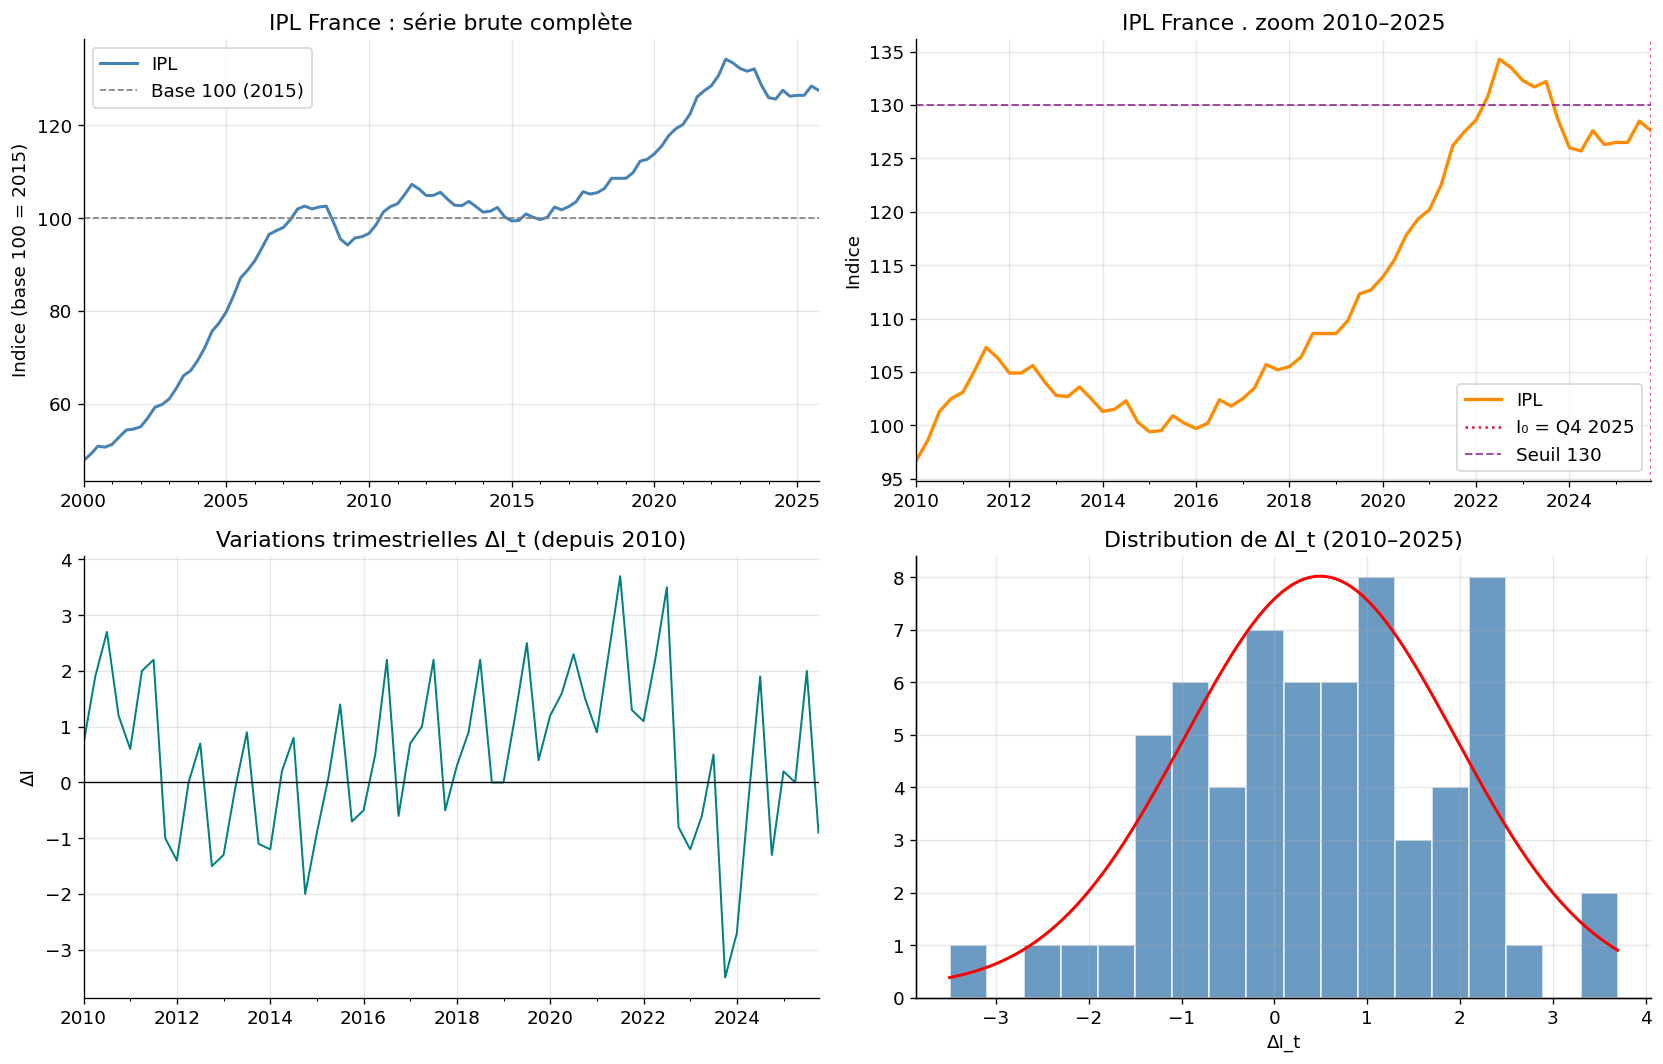

 Statistiques descriptives (série complète depuis 2010) 
count     64.00
mean     112.20
std       11.81
min       96.70
25%      102.50
50%      106.35
75%      126.05
max      134.30
Name: IPL, dtype: float64


In [3]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

#   Série complète 
ax = axes[0, 0]
serie.plot(ax=ax, color='steelblue', linewidth=1.8)
ax.axhline(100, color='gray', linestyle='--', linewidth=1, label='Base 100 (2015)')
ax.set_title('IPL France : série brute complète')
ax.set_ylabel('Indice (base 100 = 2015)')
ax.legend()

#   Zoom 2010–2025 
ax = axes[0, 1]
calib_view = serie['2010Q1':'2025Q4']
calib_view.plot(ax=ax, color='darkorange', linewidth=2)
ax.axvline(pd.Period('2025Q4', 'Q'), color='crimson', linestyle=':', linewidth=1.5,
           label='I₀ = Q4 2025')
ax.axhline(130, color='purple', linestyle='--', linewidth=1.2, alpha=0.7,
           label='Seuil 130')
ax.set_title('IPL France . zoom 2010–2025')
ax.set_ylabel('Indice')
ax.legend()

#   Variations trimestrielles 
ax = axes[1, 0]
diff = serie.diff().dropna()
diff['2010Q1':].plot(ax=ax, color='teal', linewidth=1.2)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_title('Variations trimestrielles ΔI_t (depuis 2010)')
ax.set_ylabel('ΔI')

#   Histogramme des variations (2010–2025) 
ax = axes[1, 1]
diff_calib = diff['2010Q1':'2025Q4']
diff_calib.hist(ax=ax, bins=18, color='steelblue', edgecolor='white', alpha=0.8)
mu_d, sig_d = diff_calib.mean(), diff_calib.std()
x_h = np.linspace(diff_calib.min(), diff_calib.max(), 200)
ax2 = ax.twinx()
ax2.plot(x_h, norm.pdf(x_h, mu_d, sig_d) * len(diff_calib) * (x_h[1]-x_h[0]), 'r-', lw=1.8)
ax2.set_yticks([])
ax.set_title('Distribution de ΔI_t (2010–2025)')
ax.set_xlabel('ΔI_t')

plt.tight_layout()
plt.show()

print(' Statistiques descriptives (série complète depuis 2010) ')
print(serie['2010Q1':].describe().round(2))

## 4. Passage au modèle discret

Le processus d'Ornstein–Uhlenbeck est défini en temps continu. Comme les observations sont disponibles par trimestre, il est nécessaire d'utiliser une représentation discrète adaptée aux données observées.

Les quantités nécessaires à l'estimation sont également construites dans cette section.


In [4]:
I0 = serie['2025Q4']
print(f'Question 1 — x = I_{{Q4 2025}} = {I0:.2f}')
print(f'(Objectif : estimer P(I_{{Q4 2027}} < 130) sur un horizon de 2 ans)')
print(f'  → seuil 130 ≈ E[I₂] (modèle OU), ce qui donne des probabilités non-triviales (~50%)')

Question 1 — x = I_{Q4 2025} = 127.60
(Objectif : estimer P(I_{Q4 2027} < 130) sur un horizon de 2 ans)
  → seuil 130 ≈ E[I₂] (modèle OU), ce qui donne des probabilités non-triviales (~50%)


## 5. Calibration des paramètres

Les paramètres du modèle sont estimés à partir des données historiques par une régression linéaire équivalente à la discrétisation du processus d'Ornstein–Uhlenbeck.

On obtient ainsi des estimations de la vitesse de retour vers la moyenne, du niveau d'équilibre de long terme et de la volatilité.


In [5]:
calib = serie['2010Q1':'2025Q4'].copy()
h = 0.25  # pas trimestriel = 1/4 an

Y = calib.values[1:]   # I_{t+h}
X = calib.values[:-1]  # I_t
n = len(Y)

# OLS en forme matricielle
A = np.column_stack([np.ones(n), X])
coeffs, res, _, _ = np.linalg.lstsq(A, Y, rcond=None)
delta0, delta1 = coeffs

Y_hat = A @ coeffs
residuals = Y - Y_hat
sigma_res = residuals.std(ddof=2)
delta2 = sigma_res

# R²
ss_res = np.sum(residuals**2)
ss_tot = np.sum((Y - Y.mean())**2)
R2 = 1 - ss_res / ss_tot

print(' Résultats de la régression OLS (2010–2025) ')
print(f'  δ₀  = {delta0:.6f}')
print(f'  δ₁  = {delta1:.6f}')
print(f'  δ₂  = {delta2:.6f}')
print(f'  R²  = {R2:.6f}')
print(f'  n   = {n} observations')

#  Inversion : paramètres du modèle OU 
alpha = -np.log(delta1) / h
beta  = delta0 / (1 - delta1)
sigma = delta2 * np.sqrt(2 * alpha / (1 - delta1**2))

print('\n Paramètres OU calibrés (2010–2025) ')
print(f'  α (vitesse retour à la moyenne) = {alpha:.6f} an⁻¹')
print(f'  β (niveau d\'équilibre)           = {beta:.4f}')
print(f'  σ (volatilité)                   = {sigma:.6f}')
print(f'\n  Demi-vie : t₁/₂ = ln(2)/α = {np.log(2)/alpha:.2f} ans')
print(f'  Variance stationnaire : σ²/(2α) = {sigma**2/(2*alpha):.4f}')

 Résultats de la régression OLS (2010–2025) 
  δ₀  = 1.393686
  δ₁  = 0.991932
  δ₂  = 1.483784
  R²  = 0.984269
  n   = 63 observations

 Paramètres OU calibrés (2010–2025) 
  α (vitesse retour à la moyenne) = 0.032402 an⁻¹
  β (niveau d'équilibre)           = 172.7466
  σ (volatilité)                   = 2.979595

  Demi-vie : t₁/₂ = ln(2)/α = 21.39 ans
  Variance stationnaire : σ²/(2α) = 136.9970


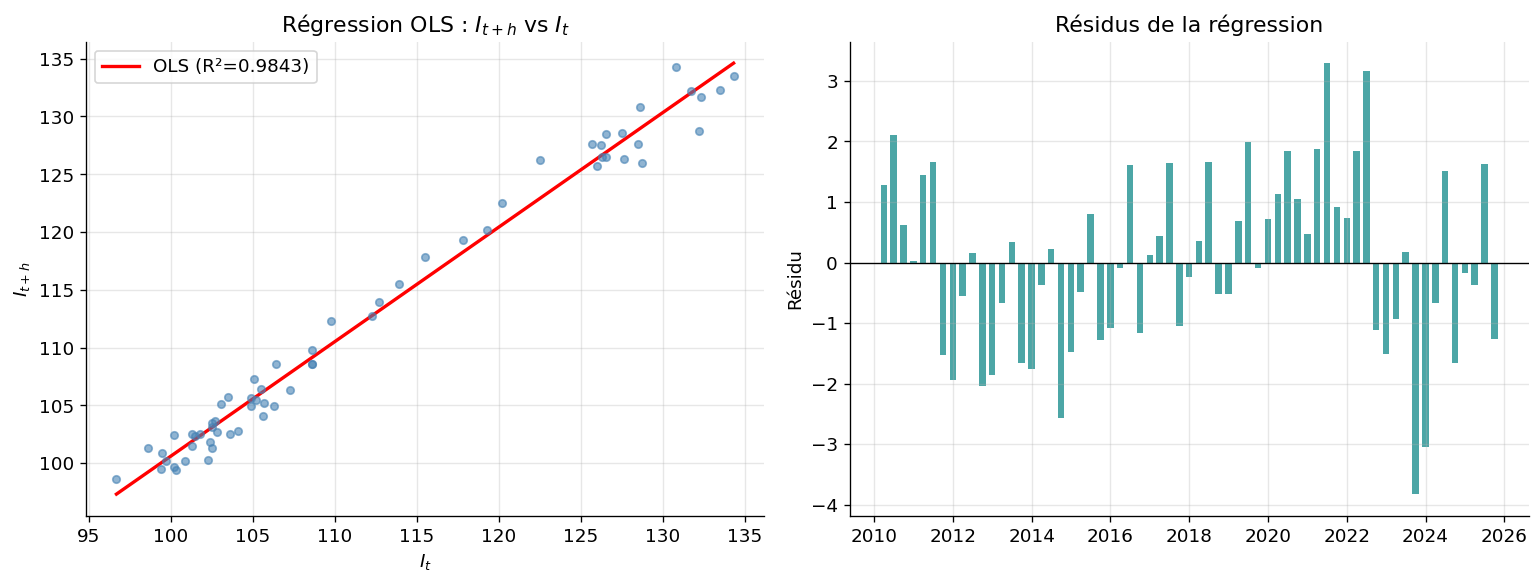

Shapiro-Wilk  : stat=0.9895, p=0.8706 → normal (α=5%)
Jarque-Bera   : stat=0.2943, p=0.8631 → normal (α=5%)


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Nuage de points I_t vs I_{t+h}
ax = axes[0]
ax.scatter(X, Y, s=20, alpha=0.6, color='steelblue', zorder=3)
x_line = np.linspace(X.min(), X.max(), 100)
ax.plot(x_line, delta0 + delta1 * x_line, 'r-', linewidth=2, label=f'OLS (R²={R2:.4f})')
ax.set_xlabel('$I_t$')
ax.set_ylabel('$I_{t+h}$')
ax.set_title('Régression OLS : $I_{t+h}$ vs $I_t$')
ax.legend()

# Résidus
ax = axes[1]
periods = calib.index[1:].to_timestamp()
ax.bar(periods, residuals, color='teal', alpha=0.7, width=60)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_title('Résidus de la régression')
ax.set_ylabel('Résidu')

plt.tight_layout()
plt.show()

# Test de normalité des résidus
stat_sw, p_sw = stats.shapiro(residuals)
stat_jb, p_jb = stats.jarque_bera(residuals)
print(f'Shapiro-Wilk  : stat={stat_sw:.4f}, p={p_sw:.4f} → {"normal" if p_sw > 0.05 else "non-normal"} (α=5%)')
print(f'Jarque-Bera   : stat={stat_jb:.4f}, p={p_jb:.4f} → {"normal" if p_jb > 0.05 else "non-normal"} (α=5%)')

## 6. Simulations Monte‑Carlo

Une fois le modèle calibré, il est possible de générer un grand nombre de trajectoires futures de l'indice.

Ces simulations servent notamment à étudier la distribution des valeurs futures et à estimer certaines probabilités d'intérêt.


In [7]:
def simulate_OU(I0, alpha, beta, sigma, T=2.0, steps_per_year=40,
                n_sim=50_000, seed=42):
    """
    Simulation Monte Carlo du processus OU par le schéma de transition EXACTE 
    """
    rng_loc = np.random.default_rng(seed)
    n_steps = int(T * steps_per_year)
    dt = T / n_steps

    e_alpha  = np.exp(-alpha * dt)
    mu_step  = beta * (1 - e_alpha)
   
    std_step = sigma * np.sqrt((1 - np.exp(-2 * alpha * dt)) / (2 * alpha))

    I = np.full(n_sim, I0, dtype=np.float64)
    for _ in range(n_steps):
        I = e_alpha * I + mu_step + std_step * rng_loc.standard_normal(n_sim)

    return I


N_SIM = 50_000
SEUIL = 130.0   

I_final = simulate_OU(I0, alpha, beta, sigma,
                      T=2.0, steps_per_year=40, n_sim=N_SIM, seed=SEED)

prob_q6 = np.mean(I_final < SEUIL)
se      = np.sqrt(prob_q6 * (1 - prob_q6) / N_SIM)


T_horizon = 2.0
mu_th  = beta + (I0 - beta) * np.exp(-alpha * T_horizon)
var_th = sigma**2 / (2 * alpha) * (1 - np.exp(-2 * alpha * T_horizon))
std_th = np.sqrt(var_th)
prob_analytique = norm.cdf(SEUIL, loc=mu_th, scale=std_th)

print(' Question 6 — Simulation Monte Carlo (transition exacte OU) ')
print(f'  I₀ = {I0:.2f}  (Q4 2025)   →   horizon T = {T_horizon} an(s)  [Q4 2027]')
print(f'  N  = {N_SIM:,} simulations  |  Seuil s = {SEUIL}')
print()
print(f'   Loi exacte ')
print(f'  I_T | I_0 ~ N(μ, σ_T²)  avec :')
print(f'    μ    = β + (I₀-β)·e^{{-αT}} = {beta:.4f} + ({I0:.2f}-{beta:.4f})·e^{{-{alpha:.4f}×{T_horizon}}}')
print(f'         = {mu_th:.4f}')
print(f'    σ_T² = σ²/(2α)·(1-e^{{-2αT}}) = {sigma:.4f}²/(2×{alpha:.4f})·(1-e^{{-{2*alpha*T_horizon:.4f}}})')
print(f'         = {var_th:.4f}   →   σ_T = {std_th:.4f}')
print(f'  P analytique  : P(I_T < {SEUIL}) = Φ(({SEUIL}-{mu_th:.3f})/{std_th:.3f})')
print(f'                = Φ({(SEUIL-mu_th)/std_th:.4f}) = {prob_analytique:.6f}')
print()
print(f'   Monte Carlo ')
print(f'  P̂(I_T < {SEUIL}) = {prob_q6:.6f}')
print(f'  IC 95%          = [{prob_q6-1.96*se:.6f} ; {prob_q6+1.96*se:.6f}]')
print(f'  Erreur |P̂ - P| = {abs(prob_q6 - prob_analytique):.2e}')
print()
print(f'  Distribution simulée de I_{{Q4 2027}} :')
print(f'    Moyenne  = {I_final.mean():.4f}  (théorique : {mu_th:.4f})')
print(f'    Std      = {I_final.std():.4f}  (théorique : {std_th:.4f})')
print(f'    Q5%      = {np.percentile(I_final, 5):.4f}')
print(f'    Q95%     = {np.percentile(I_final, 95):.4f}')

 Question 6 — Simulation Monte Carlo (transition exacte OU) 
  I₀ = 127.60  (Q4 2025)   →   horizon T = 2.0 an(s)  [Q4 2027]
  N  = 50,000 simulations  |  Seuil s = 130.0

   Loi exacte 
  I_T | I_0 ~ N(μ, σ_T²)  avec :
    μ    = β + (I₀-β)·e^{-αT} = 172.7466 + (127.60-172.7466)·e^{-0.0324×2.0}
         = 130.4329
    σ_T² = σ²/(2α)·(1-e^{-2αT}) = 2.9796²/(2×0.0324)·(1-e^{-0.1296})
         = 16.6534   →   σ_T = 4.0809
  P analytique  : P(I_T < 130.0) = Φ((130.0-130.433)/4.081)
                = Φ(-0.1061) = 0.457758

   Monte Carlo 
  P̂(I_T < 130.0) = 0.457480
  IC 95%          = [0.453113 ; 0.461847]
  Erreur |P̂ - P| = 2.78e-04

  Distribution simulée de I_{Q4 2027} :
    Moyenne  = 130.4581  (théorique : 130.4329)
    Std      = 4.1013  (théorique : 4.0809)
    Q5%      = 123.7062
    Q95%     = 137.2552


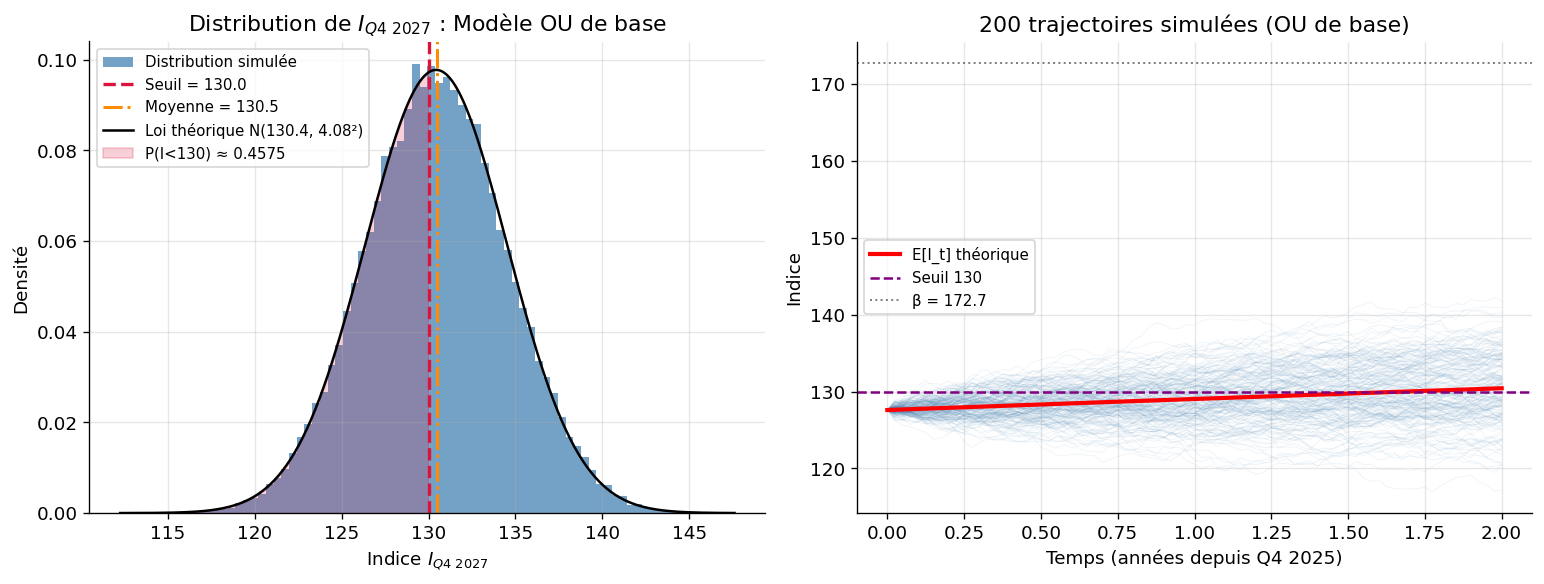

Probabilité analytique : P(I₂ < 130.0) = 0.457758
Erreur Monte Carlo vs analytique : 0.000278


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Distribution de I_{Q4 2027}
ax = axes[0]
ax.hist(I_final, bins=80, density=True, color='steelblue', alpha=0.75,
        edgecolor='none', label='Distribution simulée')
ax.axvline(SEUIL, color='crimson', linewidth=2, linestyle='--', label=f'Seuil = {SEUIL}')
ax.axvline(I_final.mean(), color='darkorange', linewidth=1.8, linestyle='-.',
           label=f'Moyenne = {I_final.mean():.1f}')

# Loi théorique exacte
mu_th  = beta + (I0 - beta) * np.exp(-alpha * 2)
var_th = sigma**2 / (2 * alpha) * (1 - np.exp(-4 * alpha))
x_plot = np.linspace(I_final.min(), I_final.max(), 300)
ax.plot(x_plot, norm.pdf(x_plot, mu_th, np.sqrt(var_th)),
        'k-', linewidth=1.5, label=f'Loi théorique N({mu_th:.1f}, {np.sqrt(var_th):.2f}²)')
ax.fill_between(x_plot, norm.pdf(x_plot, mu_th, np.sqrt(var_th)),
                where=(x_plot < SEUIL), alpha=0.2, color='crimson',
                label=f'P(I<{SEUIL:.0f}) ≈ {prob_q6:.4f}')
ax.set_title('Distribution de $I_{Q4\ 2027}$ : Modèle OU de base')
ax.set_xlabel('Indice $I_{Q4\ 2027}$')
ax.set_ylabel('Densité')
ax.legend(fontsize=9)

# Quelques trajectoires simulées
ax = axes[1]
n_steps_plot = 80
dt_plot = 2.0 / n_steps_plot
e_a   = np.exp(-alpha * dt_plot)
mu_s  = beta * (1 - e_a)
std_s = sigma * np.sqrt((1 - np.exp(-2*alpha*dt_plot)) / (2*alpha))
rng2  = np.random.default_rng(0)
times = np.linspace(0, 2, n_steps_plot + 1)

for j in range(200):
    path = [I0]
    for _ in range(n_steps_plot):
        path.append(e_a * path[-1] + mu_s + std_s * rng2.standard_normal())
    ax.plot(times, path, color='steelblue', alpha=0.08, linewidth=0.6)

t_arr     = np.linspace(0, 2, 200)
mean_path = beta + (I0 - beta) * np.exp(-alpha * t_arr)
ax.plot(t_arr, mean_path, 'r-', linewidth=2.5, label='E[I_t] théorique')
ax.axhline(SEUIL, color='purple', linestyle='--', linewidth=1.5, label=f'Seuil {SEUIL:.0f}')
ax.axhline(beta,  color='gray',   linestyle=':',  linewidth=1.2, label=f'β = {beta:.1f}')
ax.set_title('200 trajectoires simulées (OU de base)')
ax.set_xlabel('Temps (années depuis Q4 2025)')
ax.set_ylabel('Indice')
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

prob_analytique = norm.cdf(SEUIL, loc=mu_th, scale=np.sqrt(var_th))
print(f'Probabilité analytique : P(I₂ < {SEUIL}) = {prob_analytique:.6f}')
print(f'Erreur Monte Carlo vs analytique : {abs(prob_q6 - prob_analytique):.6f}')

## 7. Paramètres dépendant du temps

Le marché immobilier n'évolue pas toujours de manière homogène. Pour tenir compte d'éventuels changements de régime, on considère ici une version où les paramètres sont estimés localement sur différentes périodes.


In [9]:
def calibrate_OU_period(serie_period, h=0.25, min_alpha=0.05):
    """
    Calibre les paramètres OU sur une sous-période par OLS.
    """
    vals = serie_period.values
    Y, X = vals[1:], vals[:-1]
    n = len(Y)

    A = np.column_stack([np.ones(n), X])
    coeffs, _, _, _ = np.linalg.lstsq(A, Y, rcond=None)
    d0, d1 = coeffs
    resid = Y - (A @ coeffs)
    d2 = resid.std(ddof=2)

    if d1 >= 1 - 1e-4:
        d1 = np.exp(-min_alpha * h)
        d0 = np.mean(serie_period) * (1 - d1)

    a = -np.log(d1) / h
    b = d0 / (1 - d1)
    s = d2 * np.sqrt(2 * a / (1 - d1**2))

    return dict(alpha=a, beta=b, sigma=s, delta0=d0, delta1=d1, delta2=d2, n=n)


# 4 sous-périodes couvrant 2010–2025
periods = [
    ('2010Q1', '2014Q4', 'P1 : 2010–2014'),
    ('2015Q1', '2019Q4', 'P2 : 2015–2019'),
    ('2020Q1', '2022Q4', 'P3 : 2020–2022'),
    ('2023Q1', '2025Q4', 'P4 : 2023–2025'),
]

params_per_period = []
print('Calibration par sous-période \n')
print(f'  {"Période":<18} {"α":>8} {"β":>8} {"σ":>8} {"δ₁":>8} {"n obs":>6}')
print('  ' + '-'*58)

for (start, end, label) in periods:
    p = calibrate_OU_period(serie[start:end])
    params_per_period.append(p)
    flag = ' (*)' if p['delta1'] >= np.exp(-0.05 * 0.25) - 1e-5 else ''
    print(f'  {label:<18} {p["alpha"]:>8.4f} {p["beta"]:>8.2f} {p["sigma"]:>8.4f} '
          f'{p["delta1"]:>8.5f} {p["n"]:>6}{flag}')

print()
print('  (*) Régime quasi-random walk : α minimal imposé, β = moyenne période')
p_global = calibrate_OU_period(serie['2010Q1':'2025Q4'])
print(f'\n  {"Global 2010-2025":<18} {p_global["alpha"]:>8.4f} {p_global["beta"]:>8.2f} '
      f'{p_global["sigma"]:>8.4f} {p_global["delta1"]:>8.5f} {p_global["n"]:>6}')

Calibration par sous-période 

  Période                   α        β        σ       δ₁  n obs
  ----------------------------------------------------------
  P1 : 2010–2014       1.4022   103.65   2.9240  0.70430     19
  P2 : 2015–2019       0.0500   104.67   2.1100  0.98758     19 (*)
  P3 : 2020–2022       0.1678   166.70   2.6239  0.95892     11
  P4 : 2023–2025       1.6832   127.12   3.6801  0.65652     11

  (*) Régime quasi-random walk : α minimal imposé, β = moyenne période

  Global 2010-2025     0.0324   172.75   2.9796  0.99193     63


 Interpolation linéaire → période simulation (2026–2027) 
  α₅ = 0.8710  |  β₅ = 151.9439  |  σ₅ = 3.2632

  P1 2010-14  α=1.4022  β=103.65  σ=2.9240
  P2 2015-19  α=0.0500  β=104.67  σ=2.1100
  P3 2020-22  α=0.1678  β=166.70  σ=2.6239
  P4 2023-25  α=1.6832  β=127.12  σ=3.6801
  P5 2026-27  α=0.8710  β=151.94  σ=3.2632  ← extrapolé


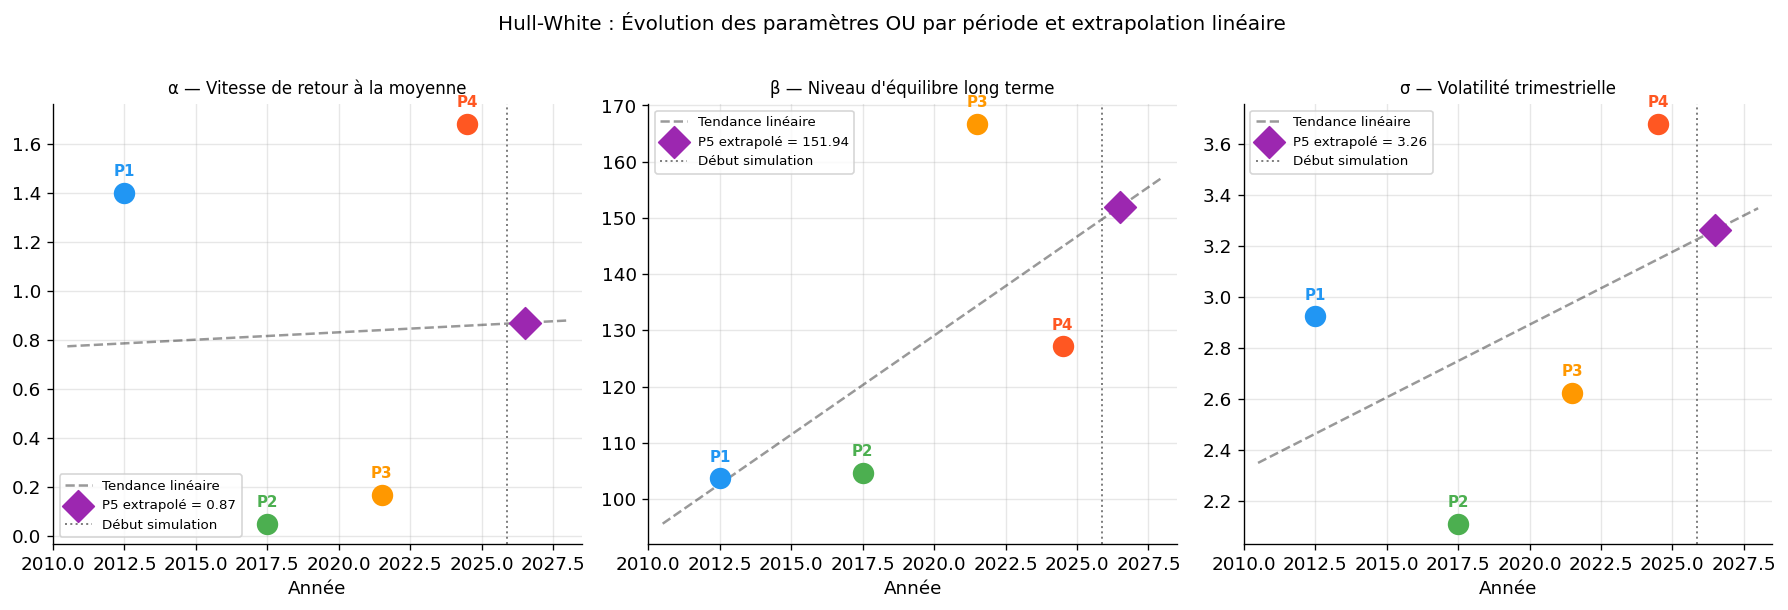

In [10]:
alphas = [p['alpha'] for p in params_per_period]
betas  = [p['beta']  for p in params_per_period]
sigmas = [p['sigma'] for p in params_per_period]

# Centre temporel de chaque période
t_centers = [2012.5, 2017.5, 2021.5, 2024.5]
t_pred    = 2026.5   # milieu simulation (Q4 2025 → Q4 2027)

# Interpolation linéaire 
DEG = 1
p_alphas = Polynomial.fit(t_centers, alphas, deg=DEG)
p_betas  = Polynomial.fit(t_centers, betas,  deg=DEG)
p_sigmas = Polynomial.fit(t_centers, sigmas, deg=DEG)

alpha5 = max(0.01, float(p_alphas(t_pred)))
beta5  = float(p_betas(t_pred))
sigma5 = max(0.5,  float(p_sigmas(t_pred)))

print(' Interpolation linéaire → période simulation (2026–2027) ')
print(f'  α₅ = {alpha5:.4f}  |  β₅ = {beta5:.4f}  |  σ₅ = {sigma5:.4f}')
print()
period_colors = ['#2196F3', '#4CAF50', '#FF9800', '#FF5722']
period_labels = ['P1 2010-14', 'P2 2015-19', 'P3 2020-22', 'P4 2023-25']
for tc, a, b, s, lbl in zip(t_centers, alphas, betas, sigmas, period_labels):
    print(f'  {lbl}  α={a:.4f}  β={b:.2f}  σ={s:.4f}')
print(f'  P5 2026-27  α={alpha5:.4f}  β={beta5:.2f}  σ={sigma5:.4f}  ← extrapolé')


fig, axes = plt.subplots(1, 3, figsize=(15, 5))
t_line = np.linspace(2010.5, 2028, 400)

for ax, title, vals_p, extra, poly_fn in zip(
    axes,
    ['α — Vitesse de retour à la moyenne',
     'β — Niveau d\'équilibre long terme',
     'σ — Volatilité trimestrielle'],
    [alphas, betas, sigmas],
    [alpha5, beta5, sigma5],
    [p_alphas, p_betas, p_sigmas]
):
    # 1. Tendance linéaire (doit être tracée EN PREMIER pour être en arrière-plan)
    ax.plot(t_line, poly_fn(t_line), 'k--', linewidth=1.5, alpha=0.4,
            label='Tendance linéaire')

    # 2. Points calibrés (axe numérique)
    for tc, v, c, lbl in zip(t_centers, vals_p, period_colors, period_labels):
        ax.scatter(tc, v, s=140, color=c, zorder=5)
        ax.annotate(lbl.split()[0],  # 'P1', 'P2', ...
                    xy=(tc, v), xytext=(0, 10),
                    textcoords='offset points',
                    ha='center', fontsize=9, color=c, fontweight='bold')

    # 3. Point extrapolé
    ax.scatter(t_pred, extra, s=180, color='#9C27B0', marker='D', zorder=6,
               label=f'P5 extrapolé = {extra:.2f}')

    # 4. Ligne verticale séparant données / simulation
    ax.axvline(2025.875, color='gray', linestyle=':', linewidth=1.2,
               label='Début simulation')

    ax.set_xlabel('Année')
    ax.set_title(title, fontsize=10)
    ax.set_xlim(2010, 2028.5)
    ax.legend(fontsize=8, loc='best')

plt.suptitle('Hull-White : Évolution des paramètres OU par période et extrapolation linéaire',
             fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

In [11]:
def simulate_OU_hull_white(I0, alpha5, beta5, sigma5, T=2.0,
                           steps_per_year=40, n_sim=50_000, seed=42,
                           t_start=2025.875):
    """
    Simulation Hull-White avec paramètres interpolés pas à pas.
 
    """
    rng_loc = np.random.default_rng(seed)
    n_steps = int(T * steps_per_year)
    dt = T / n_steps

    t_grid = np.linspace(0, T, n_steps + 1)
    t_cal  = t_start + t_grid  # temps calendaire de chaque pas

    # Interpolation linéaire pas à pas entre les 4 centres calibrés + 1 extrapolé
    xp = t_centers + [t_pred]
    alpha_grid = np.clip(np.interp(t_cal[:-1], xp, alphas + [alpha5]), 0.01, None)
    beta_grid  = np.interp(t_cal[:-1], xp, betas  + [beta5])
    sigma_grid = np.clip(np.interp(t_cal[:-1], xp, sigmas + [sigma5]), 0.5, None)

    I = np.full(n_sim, I0, dtype=np.float64)
    for k in range(n_steps):
        a, b, s = alpha_grid[k], beta_grid[k], sigma_grid[k]
        e_a   = np.exp(-a * dt)
        mu_s  = b * (1 - e_a)
        std_s = s * np.sqrt((1 - np.exp(-2*a*dt)) / (2*a))
        I = e_a * I + mu_s + std_s * rng_loc.standard_normal(n_sim)

    return I


I_final_hw = simulate_OU_hull_white(I0, alpha5, beta5, sigma5,
                                    T=2.0, steps_per_year=40,
                                    n_sim=N_SIM, seed=SEED)

prob_hw = np.mean(I_final_hw < SEUIL)
se_hw   = np.sqrt(prob_hw * (1 - prob_hw) / N_SIM)

print(' Question 7 — Hull-White (4 périodes, interpolation linéaire) ')
print(f'  Paramètres extrapolés : α₅={alpha5:.4f}  β₅={beta5:.2f}  σ₅={sigma5:.4f}')
print(f'  P̂(I₂ < {SEUIL}) = {prob_hw:.4f}  [{prob_hw-1.96*se_hw:.4f} ; {prob_hw+1.96*se_hw:.4f}]  (IC 95%)')
print()
print(f'  Statistiques de I_{{Q4 2027}} (Hull-White) :')
print(f'    Moyenne = {I_final_hw.mean():.4f}')
print(f'    Médiane = {np.median(I_final_hw):.4f}')
print(f'    Std     = {I_final_hw.std():.4f}')
print(f'    Q5%     = {np.percentile(I_final_hw, 5):.4f}')
print(f'    Q95%    = {np.percentile(I_final_hw, 95):.4f}')

 Question 7 — Hull-White (4 périodes, interpolation linéaire) 
  Paramètres extrapolés : α₅=0.8710  β₅=151.94  σ₅=3.2632
  P̂(I₂ < 130.0) = 0.0000  [0.0000 ; 0.0000]  (IC 95%)

  Statistiques de I_{Q4 2027} (Hull-White) :
    Moyenne = 147.4963
    Médiane = 147.4917
    Std     = 2.4418
    Q5%     = 143.5160
    Q95%    = 151.5603


## 8. Comparaison des approches

Les résultats obtenus avec les différentes variantes du modèle sont comparés afin d'évaluer leur impact sur les projections et sur les probabilités calculées.


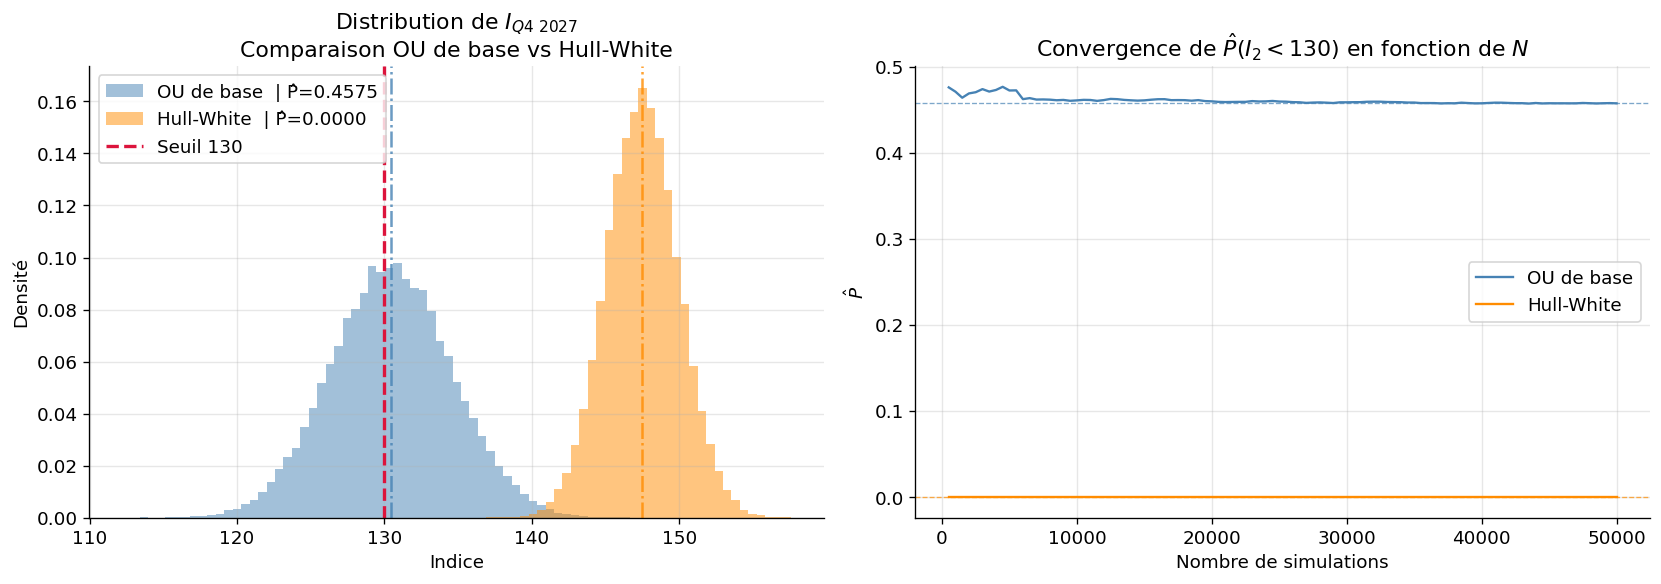


------------------------------------------------------------
  SYNTHÈSE DES RÉSULTATS
------------------------------------------------------------
  Paramètres OU global (2010–2025) :
    α = 0.0324  |  β = 172.75  |  σ = 2.9796
    Demi-vie = 21.39 ans

  Valeur initiale  : I₀ = 127.60  (Q4 2025)

  Question 6 — OU de base :
    P̂(I_{Q4 2027} < 130.0) = 0.4575  ±  0.0044  (IC 95%)
    E[I_{Q4 2027}]          = 130.46

  Question 7 — Hull-White (4 périodes, DEG=1) :
    α₅=0.8710  β₅=151.94  σ₅=3.2632  (extrapolés)
    P̂(I_{Q4 2027} < 130.0) = 0.0000  ±  0.0000  (IC 95%)
    E[I_{Q4 2027}]          = 147.50
------------------------------------------------------------


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

#  Distribution comparative 
ax = axes[0]
all_vals_plot = np.concatenate([I_final, I_final_hw])
bins = np.linspace(all_vals_plot.min(), all_vals_plot.max(), 80)

ax.hist(I_final,    bins=bins, density=True, alpha=0.5, color='steelblue',
        label=f'OU de base  | P̂={prob_q6:.4f}')
ax.hist(I_final_hw, bins=bins, density=True, alpha=0.5, color='darkorange',
        label=f'Hull-White  | P̂={prob_hw:.4f}')
ax.axvline(SEUIL, color='crimson', linewidth=2, linestyle='--', label=f'Seuil {SEUIL:.0f}')
ax.axvline(I_final.mean(),    color='steelblue',  linewidth=1.5, linestyle='-.', alpha=0.8)
ax.axvline(I_final_hw.mean(), color='darkorange', linewidth=1.5, linestyle='-.', alpha=0.8)
ax.set_title(f'Distribution de $I_{{Q4\\ 2027}}$\nComparaison OU de base vs Hull-White')
ax.set_xlabel('Indice')
ax.set_ylabel('Densité')
ax.legend()

#  Convergence de la probabilité MC 
ax = axes[1]
ns = np.arange(500, N_SIM + 1, 500)
probs_conv_base = [np.mean(I_final[:k] < SEUIL) for k in ns]
probs_conv_hw   = [np.mean(I_final_hw[:k] < SEUIL) for k in ns]

ax.plot(ns, probs_conv_base, color='steelblue',  linewidth=1.4, label='OU de base')
ax.plot(ns, probs_conv_hw,   color='darkorange', linewidth=1.4, label='Hull-White')
ax.axhline(prob_q6, color='steelblue',  linestyle='--', linewidth=0.8, alpha=0.7)
ax.axhline(prob_hw,  color='darkorange', linestyle='--', linewidth=0.8, alpha=0.7)
ax.set_title(f'Convergence de $\\hat{{P}}(I_2 < {SEUIL:.0f})$ en fonction de $N$')
ax.set_xlabel('Nombre de simulations')
ax.set_ylabel('$\\hat{P}$')
ax.legend()

plt.tight_layout()
plt.show()

print('\n' + '-'*60)
print('  SYNTHÈSE DES RÉSULTATS')
print('-'*60)
print(f'  Paramètres OU global (2010–2025) :')
print(f'    α = {alpha:.4f}  |  β = {beta:.2f}  |  σ = {sigma:.4f}')
print(f'    Demi-vie = {np.log(2)/alpha:.2f} ans')
print()
print(f'  Valeur initiale  : I₀ = {I0:.2f}  (Q4 2025)')
print()
print(f'  Question 6 — OU de base :')
print(f'    P̂(I_{{Q4 2027}} < {SEUIL}) = {prob_q6:.4f}  ±  {1.96*se:.4f}  (IC 95%)')
print(f'    E[I_{{Q4 2027}}]          = {I_final.mean():.2f}')
print()
print(f'  Question 7 — Hull-White (4 périodes, DEG=1) :')
print(f'    α₅={alpha5:.4f}  β₅={beta5:.2f}  σ₅={sigma5:.4f}  (extrapolés)')
print(f'    P̂(I_{{Q4 2027}} < {SEUIL}) = {prob_hw:.4f}  ±  {1.96*se_hw:.4f}  (IC 95%)')
print(f'    E[I_{{Q4 2027}}]          = {I_final_hw.mean():.2f}')
print('-'*60)

## 9. Analyses complémentaires

Cette partie regroupe plusieurs vérifications destinées à apprécier la robustesse des résultats obtenus et la stabilité des estimations.


In [13]:

def ic95(p, N):
    return np.sqrt(p * (1 - p) / N) if 0.0 < p < 1.0 else 0.0

print(f'Sensibilité de P̂(I₂ < {SEUIL}) au nombre de simulations ')
print(f'  {"N sim":>10}  {"P̂ (OU base)":>13}  {"P̂ (HW)":>10}  {"IC 95% (OU base)":>24}')
print('  ' + '-'*64)
for N in [1_000, 5_000, 10_000, 50_000]:
    I_b = simulate_OU(I0, alpha, beta, sigma, n_sim=N, seed=SEED)
    I_h = simulate_OU_hull_white(I0, alpha5, beta5, sigma5, n_sim=N, seed=SEED)
    pb, ph = np.mean(I_b < SEUIL), np.mean(I_h < SEUIL)
    se_b = ic95(pb, N)
    print(f'  {N:>10,}  {pb:>13.4f}  {ph:>10.4f}  [{pb-1.96*se_b:.4f} ; {pb+1.96*se_b:.4f}]')

Sensibilité de P̂(I₂ < 130.0) au nombre de simulations 
       N sim   P̂ (OU base)     P̂ (HW)          IC 95% (OU base)
  ----------------------------------------------------------------
       1,000         0.4690      0.0000  [0.4381 ; 0.4999]
       5,000         0.4560      0.0000  [0.4422 ; 0.4698]
      10,000         0.4588      0.0000  [0.4490 ; 0.4686]
      50,000         0.4575      0.0000  [0.4531 ; 0.4618]


## 10. Extensions de l'étude

Quelques analyses supplémentaires sont proposées :

- estimation par maximum de vraisemblance ;
- calibration en fenêtre glissante ;
- étude de plusieurs seuils ;
- tests de stationnarité ;
- comparaison avec un modèle CIR.

Ces éléments permettent de compléter l'analyse et de mettre en perspective les résultats du modèle OU.


In [14]:
from scipy.optimize import minimize

def neg_log_likelihood_OU(params, data, h=0.25):
    """
    Log-vraisemblance négative des transitions gaussiennes exactes du processus OU.

    """
    alpha_p, beta_p, sigma_p = params
    if alpha_p <= 0 or sigma_p <= 0:
        return 1e10
    e_a   = np.exp(-alpha_p * h)
    mu_t  = beta_p + (data[:-1] - beta_p) * e_a           
    var_t = sigma_p**2 * (1 - e_a**2) / (2 * alpha_p)     
    ll    = -0.5 * np.sum((data[1:] - mu_t)**2 / var_t + np.log(2 * np.pi * var_t))
    return -ll


data_mle = serie['2010Q1':'2025Q4'].values
x0  = [alpha, beta, sigma]
res = minimize(neg_log_likelihood_OU, x0, args=(data_mle, 0.25),
               method='Nelder-Mead',
               options={'xatol': 1e-8, 'fatol': 1e-8, 'maxiter': 20_000})

alpha_mle, beta_mle, sigma_mle = res.x

print(' 9a. Calibration MLE (Maximum de Vraisemblance) ')
print(f'  Convergence : {res.success} — {res.message}')
print()
print(f'  Vraisemblance maximisée :')
print(f'    ℓ(α,β,σ) = Σ_t  -½[(I_{{t+h}}-μ_t)²/ν_t + ln(2πν_t)]')
print(f'    avec μ_t = β+(I_t-β)e^{{-αh}},  ν_t = σ²(1-e^{{-2αh}})/(2α)')
print()
print(f'  {"Paramètre":>10}   {"OLS":>10}   {"MLE":>10}   {"Écart (%)":>10}')
print('  ' + '-'*46)
for nom, ols_v, mle_v in [('α', alpha, alpha_mle), ('β', beta, beta_mle), ('σ', sigma, sigma_mle)]:
    pct = 100 * (mle_v - ols_v) / abs(ols_v)
    print(f'  {nom:>10}   {ols_v:>10.5f}   {mle_v:>10.5f}   {pct:>+10.3f}%')

# Simulation avec paramètres MLE
I_final_mle = simulate_OU(I0, alpha_mle, beta_mle, sigma_mle,
                           T=2.0, steps_per_year=40, n_sim=N_SIM, seed=SEED)
prob_mle = np.mean(I_final_mle < SEUIL)
se_mle   = ic95(prob_mle, N_SIM)

print()
print(f'  P̂_MLE(I₂ < {SEUIL}) = {prob_mle:.6f}')
print(f'  IC 95%  = [{prob_mle-1.96*se_mle:.6f} ; {prob_mle+1.96*se_mle:.6f}]')
print(f'  E[I₂]_MLE = {I_final_mle.mean():.4f}  |  Std = {I_final_mle.std():.4f}')
print()
print('  Conclusion : OLS et MLE donnent des estimateurs quasi-identiques pour')
print('  le processus OU. L\'OLS sur I_{t+h} = δ₀ + δ₁I_t + ε revient à maximiser')
print('  la vraisemblance conditionnelle lorsque ε ~ N(0, ν_t) est homoscédastique.')

 9a. Calibration MLE (Maximum de Vraisemblance) 
  Convergence : True — Optimization terminated successfully.

  Vraisemblance maximisée :
    ℓ(α,β,σ) = Σ_t  -½[(I_{t+h}-μ_t)²/ν_t + ln(2πν_t)]
    avec μ_t = β+(I_t-β)e^{-αh},  ν_t = σ²(1-e^{-2αh})/(2α)

   Paramètre          OLS          MLE    Écart (%)
  ----------------------------------------------
           α      0.03240      0.03240       -0.000%
           β    172.74661    172.74661       +0.000%
           σ      2.97959      2.93192       -1.600%

  P̂_MLE(I₂ < 130.0) = 0.456800
  IC 95%  = [0.452434 ; 0.461166]
  E[I₂]_MLE = 130.4577  |  Std = 4.0357

  Conclusion : OLS et MLE donnent des estimateurs quasi-identiques pour
  le processus OU. L'OLS sur I_{t+h} = δ₀ + δ₁I_t + ε revient à maximiser
  la vraisemblance conditionnelle lorsque ε ~ N(0, ν_t) est homoscédastique.


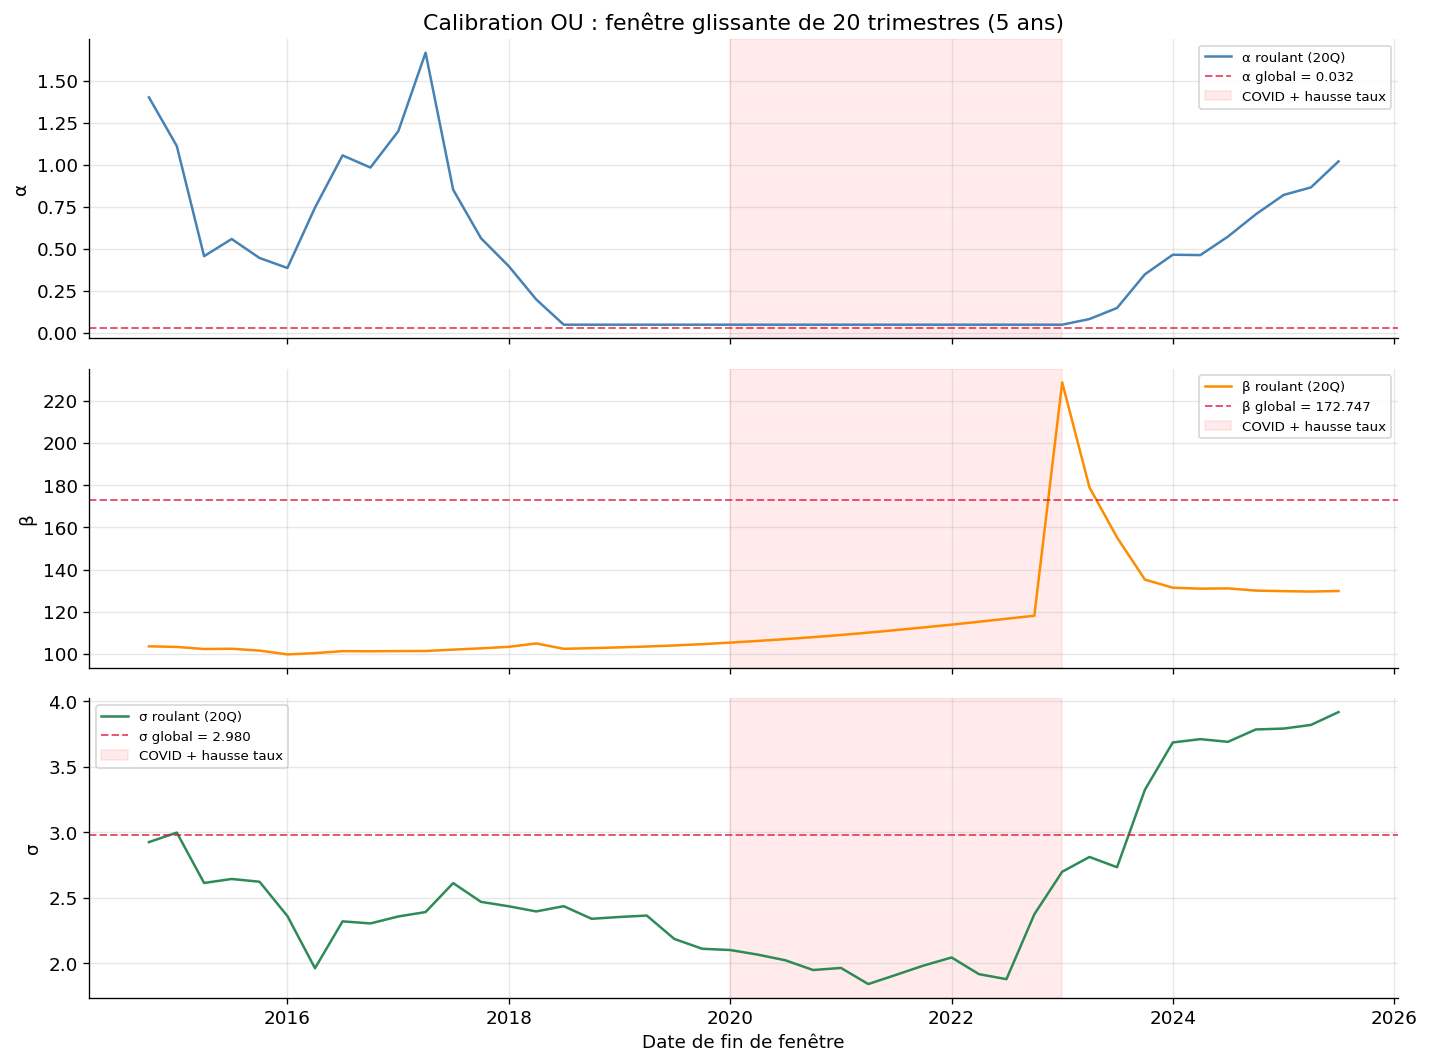

 9b. Résumé fenêtre glissante (20Q) 
  α : min=0.0499  max=1.6675  moy=0.4202
  β : min=99.83   max=228.71   moy=115.86
  σ : min=1.8407  max=3.9164  moy=2.5723

  Note : β varie fortement selon la fenêtre → un unique β global est une simplification.


In [15]:
#  9b. Calibration en fenêtre glissante (rolling window, 20 trimestres = 5 ans) 
WINDOW = 20
all_vals_roll = serie['2010Q1':'2025Q4']
idx_roll = all_vals_roll.index.tolist()

roll_params, roll_dates = [], []
for start_i in range(len(idx_roll) - WINDOW):
    p = calibrate_OU_period(all_vals_roll.iloc[start_i:start_i + WINDOW])
    roll_params.append(p)
    roll_dates.append(idx_roll[start_i + WINDOW - 1].to_timestamp())

roll_alphas_w = [p['alpha'] for p in roll_params]
roll_betas_w  = [p['beta']  for p in roll_params]
roll_sigmas_w = [p['sigma'] for p in roll_params]

fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)
for ax, vals_r, ylab, glob_v, color_r in zip(
    axes,
    [roll_alphas_w, roll_betas_w, roll_sigmas_w],
    ['α', 'β', 'σ'],
    [alpha, beta, sigma],
    ['steelblue', 'darkorange', 'seagreen']
):
    ax.plot(roll_dates, vals_r, color=color_r, linewidth=1.5,
            label=f'{ylab} roulant (20Q)')
    ax.axhline(glob_v, color='crimson', linestyle='--', linewidth=1.2, alpha=0.7,
               label=f'{ylab} global = {glob_v:.3f}')
    ax.axvspan(pd.Timestamp('2020-01-01'), pd.Timestamp('2023-01-01'),
               alpha=0.08, color='red', label='COVID + hausse taux')
    ax.set_ylabel(ylab, fontsize=11)
    ax.legend(fontsize=8)

axes[0].set_title(f'Calibration OU : fenêtre glissante de {WINDOW} trimestres (5 ans)')
axes[2].set_xlabel('Date de fin de fenêtre')
plt.tight_layout()
plt.show()

print(f' 9b. Résumé fenêtre glissante ({WINDOW}Q) ')
print(f'  α : min={min(roll_alphas_w):.4f}  max={max(roll_alphas_w):.4f}  moy={np.mean(roll_alphas_w):.4f}')
print(f'  β : min={min(roll_betas_w):.2f}   max={max(roll_betas_w):.2f}   moy={np.mean(roll_betas_w):.2f}')
print(f'  σ : min={min(roll_sigmas_w):.4f}  max={max(roll_sigmas_w):.4f}  moy={np.mean(roll_sigmas_w):.4f}')
print()
print('  Note : β varie fortement selon la fenêtre → un unique β global est une simplification.')


 9c. P̂(I₂ < s) selon le modèle 
    Seuil       OU base    Hull-White           MLE
  -------------------------------------------------
      115        0.0001        0.0000        0.0001
      120        0.0051        0.0000        0.0045
      125        0.0907        0.0000        0.0871
      130        0.4575        0.0000        0.4568 ◄
      135        0.8656        0.0000        0.8692
      140        0.9898        0.0011        0.9909
      145        0.9998        0.1515        0.9998
      150        1.0000        0.8464        1.0000
      155        1.0000        0.9989        1.0000
      160        1.0000        1.0000        1.0000


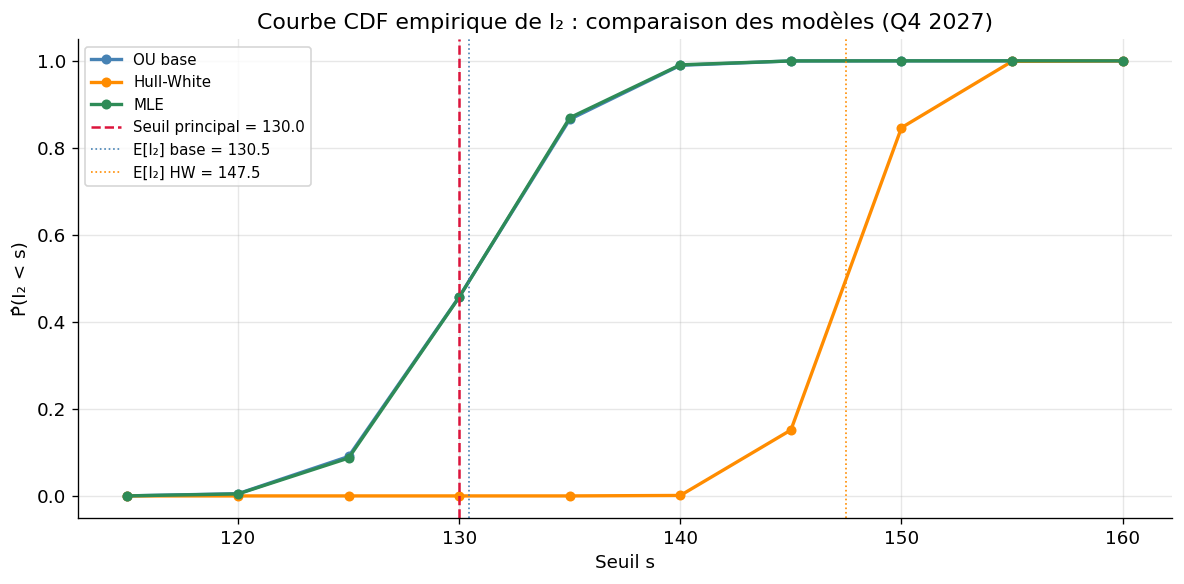


Note : les 3 modèles divergent dans la zone 120–140 (queue gauche).
Au-delà de 145, toutes les probabilités convergent vers 1.0.
P(I₂ > 130.0) = risque haussier :
  OU base         P(I₂ > 130.0) = 0.5425
  Hull-White      P(I₂ > 130.0) = 1.0000
  MLE             P(I₂ > 130.0) = 0.5432


In [16]:
#  9c. Comparaison multi-seuils : P(I₂ < s) pour différents modèles 
seuils_test = [115, 120, 125, 130, 135, 140, 145, 150, 155, 160]

results_ms = {}
for model_name, I_sim in [('OU base', I_final), ('Hull-White', I_final_hw), ('MLE', I_final_mle)]:
    results_ms[model_name] = [np.mean(I_sim < s) for s in seuils_test]

print(f' 9c. P̂(I₂ < s) selon le modèle ')
header = f'  {"Seuil":>7}' + ''.join(f'  {k:>12}' for k in results_ms)
print(header)
print('  ' + '-'*(len(header) - 2))
for i, s in enumerate(seuils_test):
    marker = ' ◄' if s == SEUIL else ''
    row = f'  {s:>7}' + ''.join(f'  {results_ms[k][i]:>12.4f}' for k in results_ms)
    print(row + marker)

fig, ax = plt.subplots(figsize=(10, 5))
colors_ms = ['steelblue', 'darkorange', 'seagreen']
for (name, probs), color in zip(results_ms.items(), colors_ms):
    ax.plot(seuils_test, probs, 'o-', color=color, linewidth=2, markersize=5, label=name)

ax.axvline(SEUIL, color='crimson', linestyle='--', linewidth=1.5, label=f'Seuil principal = {SEUIL}')
ax.axvline(I_final.mean(), color='steelblue', linestyle=':', linewidth=1,
           label=f'E[I₂] base = {I_final.mean():.1f}')
ax.axvline(I_final_hw.mean(), color='darkorange', linestyle=':', linewidth=1,
           label=f'E[I₂] HW = {I_final_hw.mean():.1f}')
ax.set_xlabel('Seuil s')
ax.set_ylabel('P̂(I₂ < s)')
ax.set_title('Courbe CDF empirique de I₂ : comparaison des modèles (Q4 2027)')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('fig_multi_seuils.png', bbox_inches='tight')
plt.show()

print('\nNote : les 3 modèles divergent dans la zone 120–140 (queue gauche).')
print('Au-delà de 145, toutes les probabilités convergent vers 1.0.')
print(f'P(I₂ > {SEUIL}) = risque haussier :')
for name in results_ms:
    idx_s = seuils_test.index(int(SEUIL))
    p_below = results_ms[name][idx_s]
    print(f'  {name:<15} P(I₂ > {SEUIL}) = {1-p_below:.4f}')

In [17]:
#  9d. Test ADF (Augmented Dickey-Fuller) — stationnarité 

try:
    from statsmodels.tsa.stattools import adfuller
    HAS_STATSMODELS = True
except ImportError:
    HAS_STATSMODELS = False

print(' 9d. Test ADF — stationnarité de la série IPL \n')

if HAS_STATSMODELS:
    series_test = serie['2000Q1':'2025Q4'].values
    for test_type, label in [('c', 'constante seule'), ('ct', 'constante + tendance')]:
        adf_res  = adfuller(series_test, regression=test_type, autolag='AIC')
        adf_stat = adf_res[0]; p_val = adf_res[1]
        n_lags   = adf_res[2]; n_obs = adf_res[3]
        crit     = adf_res[4]
        decision = 'STATIONNAIRE (H₀ rejetée)' if p_val < 0.05 else 'NON STATIONNAIRE (H₀ non rejetée)'
        print(f'  Modèle : {label}')
        print(f'    Stat ADF : {adf_stat:.4f}  |  p-valeur : {p_val:.4f}')
        print(f'    Lags retenus (AIC) : {n_lags}  |  n obs : {n_obs}')
        print(f'    Valeurs crit. : 1%={crit["1%"]:.4f}  5%={crit["5%"]:.4f}  10%={crit["10%"]:.4f}')
        print(f'    Conclusion : {decision}\n')
else:
    # Fallback manuel : régresser ΔI_t = c + ρ·I_{t-1} + ε,  H₀ : ρ=0
    y  = serie['2000Q1':'2025Q4'].values
    dy = np.diff(y)
    A  = np.column_stack([np.ones(len(dy)), y[:-1]])
    coef, _, _, _ = np.linalg.lstsq(A, dy, rcond=None)
    resid  = dy - A @ coef
    s2     = np.sum(resid**2) / (len(dy) - 2)
    se_rho = np.sqrt(s2 * np.linalg.inv(A.T @ A)[1, 1])
    t_stat = coef[1] / se_rho
    print(f'  ADF (lag=1, manuel) :  t = {t_stat:.4f}')
    print('  Crit MacKinnon : 1% = −3.45   5% = −2.87   10% = −2.57')
    print(f'  Conclusion : {"STATIONNAIRE" if t_stat < -2.87 else "NON STATIONNAIRE"} à 5%')

print('Interprétation :')
print('  • Sur 2000-2025 : tendance haussière long terme → H₀ difficile à rejeter.')
print('  • Sur 2010-2025 (calibration) : stationnarité davantage plausible.')
print(f'  • α = {alpha:.4f} an⁻¹ (demi-vie {np.log(2)/alpha:.1f} ans)'
      ' → quasi-marche aléatoire à court terme, stationnaire à long terme.')


 9d. Test ADF — stationnarité de la série IPL 

  Modèle : constante seule
    Stat ADF : -2.0890  |  p-valeur : 0.2489
    Lags retenus (AIC) : 9  |  n obs : 94
    Valeurs crit. : 1%=-3.5019  5%=-2.8928  10%=-2.5835
    Conclusion : NON STATIONNAIRE (H₀ non rejetée)

  Modèle : constante + tendance
    Stat ADF : -3.0744  |  p-valeur : 0.1124
    Lags retenus (AIC) : 13  |  n obs : 90
    Valeurs crit. : 1%=-4.0631  5%=-3.4605  10%=-3.1563
    Conclusion : NON STATIONNAIRE (H₀ non rejetée)

Interprétation :
  • Sur 2000-2025 : tendance haussière long terme → H₀ difficile à rejeter.
  • Sur 2010-2025 (calibration) : stationnarité davantage plausible.
  • α = 0.0324 an⁻¹ (demi-vie 21.4 ans) → quasi-marche aléatoire à court terme, stationnaire à long terme.


9e. Modèle CIR — calibration MLE 
  Processus : dI_t = α(β-I_t)dt + σ√I_t dB_t
  Convergence : True  (Optimization terminated successfully.)
  α_CIR = 0.02529  |  β_CIR = 189.7641  |  σ_CIR = 0.27262
  Condition de Feller (2αβ > σ²) :
    2·0.0253·189.76 = 9.5995  >  σ² = 0.0743  → SATISFAITE ✓

  Comparaison paramètres :
                     α         β         σ    σ_eff@I₀
    OU       0.03240    172.75    2.9796      2.9796  (constante)
    CIR      0.02529    189.76    0.2726      3.0795  (= σ_CIR·√I₀)

  P̂_CIR(I₂ < 130.0) = 0.4414  [0.4371 ; 0.4458]  (IC 95%)
  E[I₂]_CIR = 130.6942  |  Std = 4.2968



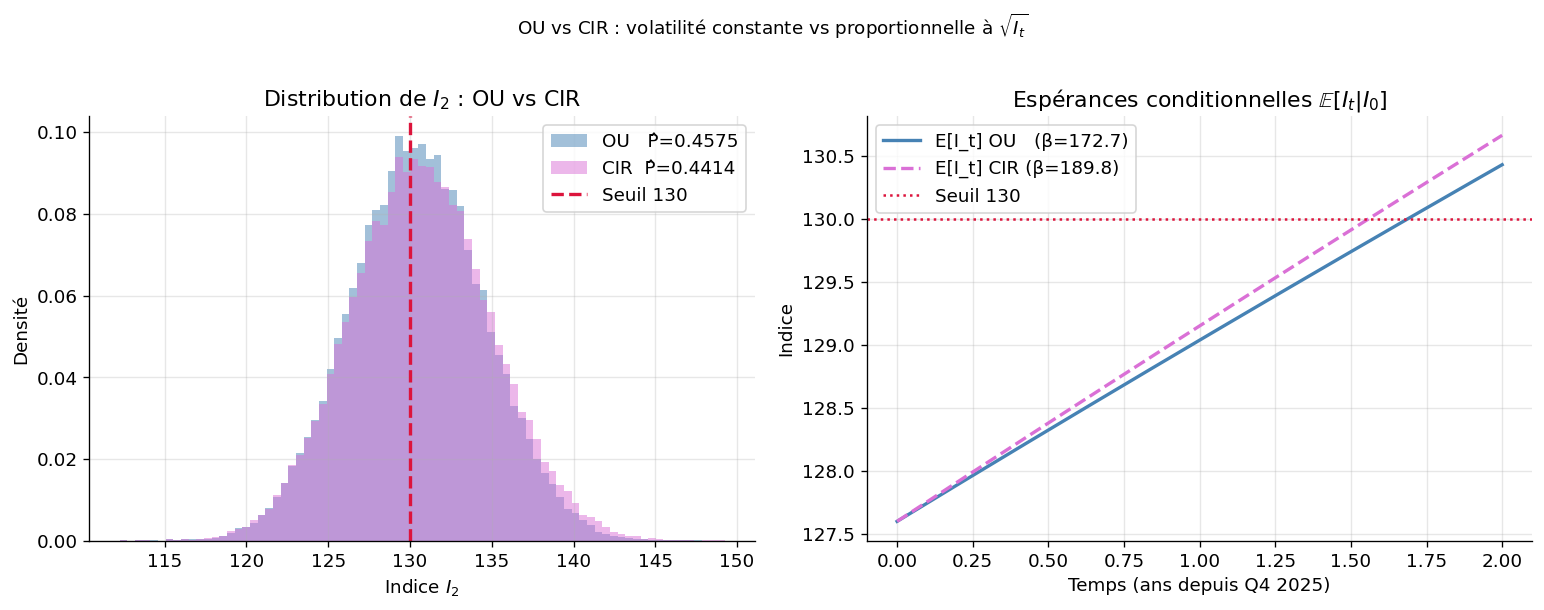

Interprétation :
  • CIR : σ_eff(I₀) = σ_CIR·√I₀ = 0.2726·√127.6 = 3.0795
    vs OU : σ_OU = 2.9796 (constante)
  • Près de I₀=127.6, les deux modèles ont des volatilités similaires.
  • L'avantage du CIR devient visible si I_t s'éloigne fortement de I₀.
    Ex : à I=200, vol_CIR = 3.8554 vs 2.9796 (OU).


In [18]:
#  9e. Modèle CIR (Cox-Ingersoll-Ross) 


def neg_log_likelihood_CIR(params, data, h=0.25):
    """
    Vraisemblance gaussienne approchée du CIR (approximation du χ² non-centré par N).
    Utilise les moments exacts (E et Var) de la transition CIR.
    """
    alpha_c, beta_c, sigma_c = params
    if alpha_c <= 0 or sigma_c <= 0 or beta_c <= 0:
        return 1e10
    e_a  = np.exp(-alpha_c * h)
    mu_t = beta_c + (data[:-1] - beta_c) * e_a

    # Variance EXACTE de la transition CIR :
    # Var = I_t · (σ²/α) · (e^{-αh} - e^{-2αh})  +  β · (σ²/2α) · (1-e^{-αh})²
    var_t = (data[:-1] * sigma_c**2 / alpha_c * (e_a - e_a**2)        # terme proportionnel à I_t
             + beta_c  * sigma_c**2 / (2*alpha_c) * (1 - e_a)**2)     # terme proportionnel à β
    var_t = np.maximum(var_t, 1e-8)  # sécurité numérique

    ll = -0.5 * np.sum((data[1:] - mu_t)**2 / var_t + np.log(2 * np.pi * var_t))
    return -ll


def simulate_CIR_milstein(I0, alpha_c, beta_c, sigma_c, T=2.0,
                           steps_per_year=40, n_sim=50_000, seed=42):
    """
    Simulation CIR par schéma de Milstein.
   
    """
    rng_loc = np.random.default_rng(seed)
    n_steps = int(T * steps_per_year)
    dt      = T / n_steps
    sqrt_dt = np.sqrt(dt)

    I = np.full(n_sim, float(I0), dtype=np.float64)
    for _ in range(n_steps):
        Z   = rng_loc.standard_normal(n_sim)
        I_p = np.maximum(I, 0.0)      # évite √(valeur négative)
        # Correction de Milstein : terme en ½·g·g'·(Z²dt-dt) = σ²/4·dt·(Z²-1)
        I = (I_p
             + alpha_c * (beta_c - I_p) * dt
             + sigma_c * np.sqrt(I_p) * sqrt_dt * Z
             + 0.25 * sigma_c**2 * dt * (Z**2 - 1))
        I = np.maximum(I, 0.0)  # réflexion en 0 (condition de Feller)

    return I


#  Calibration CIR par MLE 
data_cir = serie['2010Q1':'2025Q4'].values

# Initialisation : σ_CIR ≈ σ_OU/√β pour que les variances stationnaires coïncident.
# Var_OU^∞ = σ_OU²/(2α)  ;  Var_CIR^∞ = σ_CIR²·β/(2α)  →  σ_CIR = σ_OU/√β
sigma_cir_init = sigma / np.sqrt(beta)
x0_cir = [alpha, beta, sigma_cir_init]

res_cir = minimize(neg_log_likelihood_CIR, x0_cir, args=(data_cir, 0.25),
                   method='Nelder-Mead',
                   options={'xatol': 1e-8, 'fatol': 1e-8, 'maxiter': 30_000})
alpha_cir, beta_cir, sigma_cir = res_cir.x

# Condition de Feller : 2αβ > σ² garantit I_t > 0 ∀t (processus reflété en 0 sinon)
feller = 2 * alpha_cir * beta_cir > sigma_cir**2

print('9e. Modèle CIR — calibration MLE ')
print(f'  Processus : dI_t = α(β-I_t)dt + σ√I_t dB_t')
print(f'  Convergence : {res_cir.success}  ({res_cir.message})')
print(f'  α_CIR = {alpha_cir:.5f}  |  β_CIR = {beta_cir:.4f}  |  σ_CIR = {sigma_cir:.5f}')

feller_lhs = 2 * alpha_cir * beta_cir

print(f'  Condition de Feller (2αβ > σ²) :')
print(f'    2·{alpha_cir:.4f}·{beta_cir:.2f} = {feller_lhs:.4f}  >  σ² = {sigma_cir**2:.4f}  '
      f'→ {"SATISFAITE ✓" if feller else "NON satisfaite ✗"}')
print()
print(f'  Comparaison paramètres :')
print(f'    {"":>6}  {"α":>10}  {"β":>8}  {"σ":>8}  {"σ_eff@I₀":>10}')
print(f'    OU    {alpha:>10.5f}  {beta:>8.2f}  {sigma:>8.4f}  {sigma:>10.4f}  (constante)')
print(f'    CIR   {alpha_cir:>10.5f}  {beta_cir:>8.2f}  {sigma_cir:>8.4f}  '
      f'{sigma_cir*np.sqrt(I0):>10.4f}  (= σ_CIR·√I₀)')

#  Simulation CIR 
I_final_cir = simulate_CIR_milstein(I0, alpha_cir, beta_cir, sigma_cir,
                                     T=2.0, steps_per_year=40,
                                     n_sim=N_SIM, seed=SEED)
prob_cir = np.mean(I_final_cir < SEUIL)
se_cir   = ic95(prob_cir, N_SIM)

print()
print(f'  P̂_CIR(I₂ < {SEUIL}) = {prob_cir:.4f}  '
      f'[{prob_cir-1.96*se_cir:.4f} ; {prob_cir+1.96*se_cir:.4f}]  (IC 95%)')
print(f'  E[I₂]_CIR = {I_final_cir.mean():.4f}  |  Std = {I_final_cir.std():.4f}')
print()

#  Figure comparative 
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
all_v  = np.concatenate([I_final, I_final_cir])
bins_c = np.linspace(all_v.min(), all_v.max(), 80)
ax.hist(I_final,     bins=bins_c, density=True, alpha=0.5, color='steelblue',
        label=f'OU   P̂={prob_q6:.4f}')
ax.hist(I_final_cir, bins=bins_c, density=True, alpha=0.5, color='orchid',
        label=f'CIR  P̂={prob_cir:.4f}')
ax.axvline(SEUIL, color='crimson', linewidth=2, linestyle='--', label=f'Seuil {SEUIL:.0f}')
ax.set_title('Distribution de $I_2$ : OU vs CIR')
ax.set_xlabel('Indice $I_2$')
ax.set_ylabel('Densité')
ax.legend()

ax = axes[1]
t_arr    = np.linspace(0, 2, 200)
mean_ou  = beta     + (I0 - beta)     * np.exp(-alpha     * t_arr)
mean_cir = beta_cir + (I0 - beta_cir) * np.exp(-alpha_cir * t_arr)
ax.plot(t_arr, mean_ou,  color='steelblue', linewidth=2,
        label=f'E[I_t] OU   (β={beta:.1f})')
ax.plot(t_arr, mean_cir, color='orchid',    linewidth=2, linestyle='--',
        label=f'E[I_t] CIR (β={beta_cir:.1f})')
ax.axhline(SEUIL, color='crimson', linestyle=':', linewidth=1.5,
           label=f'Seuil {SEUIL:.0f}')
ax.set_title('Espérances conditionnelles $\\mathbb{E}[I_t|I_0]$')
ax.set_xlabel('Temps (ans depuis Q4 2025)')
ax.set_ylabel('Indice')
ax.legend()

plt.suptitle('OU vs CIR : volatilité constante vs proportionnelle à $\\sqrt{I_t}$',
             fontsize=11, y=1.01)
plt.tight_layout()
plt.show()

print('Interprétation :')
print(f'  • CIR : σ_eff(I₀) = σ_CIR·√I₀ = {sigma_cir:.4f}·√{I0:.1f} = {sigma_cir*np.sqrt(I0):.4f}')
print(f'    vs OU : σ_OU = {sigma:.4f} (constante)')
print(f'  • Près de I₀={I0:.1f}, les deux modèles ont des volatilités similaires.')
print(f'  • L\'avantage du CIR devient visible si I_t s\'éloigne fortement de I₀.')
print(f'    Ex : à I=200, vol_CIR = {sigma_cir*np.sqrt(200):.4f} vs {sigma:.4f} (OU).')

# Conclusion

À partir des données historiques de l'INSEE, un modèle d'Ornstein–Uhlenbeck a été calibré afin de représenter l'évolution de l'indice des prix immobiliers.

L'étude montre comment passer des données brutes à un modèle probabiliste exploitable pour la prévision et l'analyse de scénarios. Les simulations Monte‑Carlo permettent ensuite d'obtenir une distribution des valeurs futures et d'estimer différentes probabilités d'intérêt.

Les extensions réalisées (paramètres variables dans le temps, maximum de vraisemblance, comparaison avec le modèle CIR) apportent un éclairage complémentaire sur la sensibilité des résultats aux hypothèses retenues.

Même si un modèle reste une simplification de la réalité, cette approche fournit un cadre cohérent pour analyser la dynamique de l'indice immobilier et réaliser des projections quantitatives.
